**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
M.C. Joan Manuel Raygoza Romero

# ICD - 9: Ingeniería de características

Sesión 9 del curso. Diapositivas: [icd-09-seleccion.pdf](https://github.com/husseinlopez/icd2026/blob/main/clases/icd-09-seleccion.pdf)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/husseinlopez/icd2026/blob/main/icd-09-seleccion.ipynb)

Usaremos un mismo conjunto de datos y un clasificador sencillo. Las explicaciones preceden al código y las salidas quedan incluidas. Ejecuta las celdas en orden; los datos están incluidos en scikit-learn, por lo que no necesitas descargar archivos.

| Recorrido | Técnicas |
|---|---|
| 1–3. Preparación | Datos, particiones y modelo de referencia |
| 4. Filtros | Varianza, Pearson, Spearman, ANOVA, chi-cuadrada e información mutua |
| 5. Wrappers | Forward, backward y RFE |
| 6. Embebidos | Penalizaciones L1 / Elastic Net e importancia de árboles |
| 7. Búsqueda global | Recocido simulado con una máscara binaria |
| 8–9. Interpretación y comparación | Permutación, desempeño, tamaño y prueba final |
| 10. Actividades | Interacciones XOR y ejercicios |

## 1. Bibliotecas y configuración
Necesitamos NumPy, pandas, Matplotlib y scikit-learn. El notebook usa la API de scikit-learn **1.8 o posterior** para las penalizaciones de regresión logística y fue comprobado con la versión 1.8.0.

Si falta alguna biblioteca, ejecuta en una celda y después reinicia el kernel:
```python
%pip install numpy pandas matplotlib "scikit-learn>=1.8,<2"
```

`SEED` hace reproducibles las particiones y los procesos aleatorios. `K` fija cuántas variables conservarán los métodos top-k; no todos los métodos tienen que devolver la misma cantidad.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from time import perf_counter
from IPython.display import display

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, f_classif, chi2,
    mutual_info_classif, SequentialFeatureSelector, RFE, SelectFromModel
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

SEED = 42
K = 5
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11})
pd.set_option('display.max_colwidth', 90)
print('scikit-learn:', sklearn.__version__)

scikit-learn: 1.6.1


## 2. Datos: clasificación de vinos
`load_wine` contiene **178 muestras, 13 mediciones numéricas y 3 clases** de vino. Cada fila representa una muestra; el objetivo es identificar su clase a partir de sus mediciones químicas. Los códigos 0, 1 y 2 son etiquetas, **no una escala de calidad**.

Añadiremos tres columnas didácticas: una constante, una copia de `alcohol` y ruido independiente. Esto permite observar si cada técnica elimina variables sin variación, redundantes o sin relación generadora con el objetivo. El ruido puede mostrar correlaciones accidentales en una muestra pequeña.

In [2]:
datos = load_wine(as_frame=True)
X = datos.data.copy()
y = datos.target.rename('clase')

rng = np.random.default_rng(SEED)
X['constante'] = 1.0
X['alcohol_copia'] = X['alcohol']
X['ruido'] = rng.normal(size=len(X))

print('Dimensiones con las columnas didácticas:', X.shape)
print('Faltantes:', int(X.isna().sum().sum()))
display(X.head())
display(y.value_counts().sort_index().rename('muestras').to_frame())

Dimensiones con las columnas didácticas: (178, 16)
Faltantes: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,constante,alcohol_copia,ruido
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,1.0,14.23,0.304717
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,1.0,13.20,-1.039984
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,1.0,13.16,0.750451
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,1.0,14.37,0.940565
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,1.0,13.24,-1.951035


,muestras
clase,
0,59
1,71
2,48


### Diccionario breve
Conservamos los nombres originales para relacionarlos con la documentación. No se necesitan conversiones de unidades para esta práctica; sus escalas diferentes motivan el uso de estandarización en los modelos lineales.

In [3]:
descripciones = [
    'Alcohol', 'Ácido málico', 'Cenizas', 'Alcalinidad de las cenizas',
    'Magnesio', 'Fenoles totales', 'Flavonoides', 'Fenoles no flavonoides',
    'Proantocianinas', 'Intensidad del color', 'Tono del color',
    'Relación OD280/OD315 de vinos diluidos', 'Prolina',
    'Valor fijo: no aporta variación', 'Copia exacta de alcohol',
    'Ruido normal generado de forma independiente'
]
display(pd.DataFrame({'variable': X.columns, 'descripción': descripciones}))

,variable,descripción
0,alcohol,Alcohol
1,malic_acid,Ácido málico
2,ash,Cenizas
3,alcalinity_of_ash,Alcalinidad de las cenizas
4,magnesium,Magnesio
5,total_phenols,Fenoles totales
6,flavanoids,Flavonoides
7,nonflavanoid_phenols,Fenoles no flavonoides
8,proanthocyanins,Proantocianinas
9,color_intensity,Intensidad del color


## 3. Separar antes de seleccionar
Crearemos tres particiones estratificadas, aproximadamente **60 % entrenamiento, 20 % validación y 20 % prueba**.

- **Entrenamiento:** calcular puntuaciones, ajustar selectores y entrenar modelos. Los wrappers usarán validación cruzada de tres particiones dentro de este conjunto.
- **Validación:** comparar los métodos ya definidos y elegir una alternativa.
- **Prueba:** evaluar una sola vez la alternativa elegida, al final.

La estandarización se ajusta dentro de un `Pipeline`. Así, en los wrappers, cada partición de validación cruzada recibe medias y desviaciones aprendidas únicamente de su entrenamiento. Nunca se usa prueba para seleccionar columnas.

In [4]:
X_desarrollo, X_test, y_desarrollo, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_desarrollo, y_desarrollo, test_size=0.25,
    stratify=y_desarrollo, random_state=SEED
)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

def crear_modelo():
    # El mismo clasificador final se utilizará para todos los subconjuntos.
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(C=1.0, max_iter=3000, random_state=SEED)
    )

print(f'Entrenamiento: {len(X_train)} | Validación: {len(X_val)} | Prueba: {len(X_test)}')
subconjuntos = {'Sin selección': X.columns.tolist()}
tiempos_seleccion = {'Sin selección': 0.0}

Entrenamiento: 106 | Validación: 36 | Prueba: 36


### Métrica común
Usaremos F1 macro: calculamos F1 para cada clase y luego promediamos, dando el mismo peso a las tres clases.

$$F1_{macro}=\frac{1}{C}\sum_{c=1}^{C}\frac{2P_cR_c}{P_c+R_c}.$$

Un valor cercano a 1 indica buen desempeño. También reportaremos exactitud (*accuracy*), número de variables y tiempo de selección. Primero entrenamos una referencia con todas las columnas.

In [5]:
modelo_base = crear_modelo().fit(X_train, y_train)
pred_base = modelo_base.predict(X_val)
print(f'F1 macro de referencia en validación: {f1_score(y_val, pred_base, average="macro"):.3f}')

F1 macro de referencia en validación: 1.000


## 4. Métodos filter
### 4.1. Varianza: eliminar columnas constantes
La varianza mide cuánto cambia una variable:

$$\operatorname{Var}(x_j)=\frac{1}{n}\sum_{i=1}^{n}(x_{ij}-\bar{x}_j)^2.$$

Con `threshold=0` solo eliminamos columnas constantes. Un umbral positivo elimina también columnas con poca variación, pero depende de las unidades: no sería razonable comparar directamente la varianza del alcohol con la de la prolina. Estandarizar primero todas las variables tampoco resuelve ese criterio, pues las no constantes pasarían a tener varianza unitaria.

Esta primera máscara se usará como limpieza común antes de los demás filtros y de la selección integrada. Los wrappers trabajarán con todas las columnas para ajustar su escalado en cada fold.

In [6]:
t0 = perf_counter()
filtro_var = VarianceThreshold(threshold=0.0).fit(X_train)
columnas_variables = X_train.columns[filtro_var.get_support()].tolist()
subconjuntos['Varianza'] = columnas_variables
tiempos_seleccion['Varianza'] = perf_counter() - t0

# Vista del entrenamiento sin columnas constantes.
Xt = X_train[columnas_variables]
print('Eliminadas:', X_train.columns[~filtro_var.get_support()].tolist())
display(pd.Series(filtro_var.variances_, index=X_train.columns, name='varianza').to_frame())

Eliminadas: ['constante']


,varianza
alcohol,0.619787
malic_acid,1.159448
ash,0.068633
alcalinity_of_ash,10.763233
magnesium,84.000000
total_phenols,0.415395
flavanoids,0.929682
nonflavanoid_phenols,0.014637
proanthocyanins,0.327860
color_intensity,4.906243


### 4.2. Correlación entre características: Pearson y Spearman
Pearson detecta asociación lineal; Spearman utiliza rangos y detecta asociación monótona. Para reducir redundancia eliminaremos una variable cuando tenga correlación absoluta mayor a **0.95** con alguna ya conservada.

$$|r(x_j,x_k)|>0.95.$$

El algoritmo conserva la primera columna de cada pareja redundante. Por tanto, el orden influye en el resultado; aquí no se decide cuál es más útil para el objetivo.

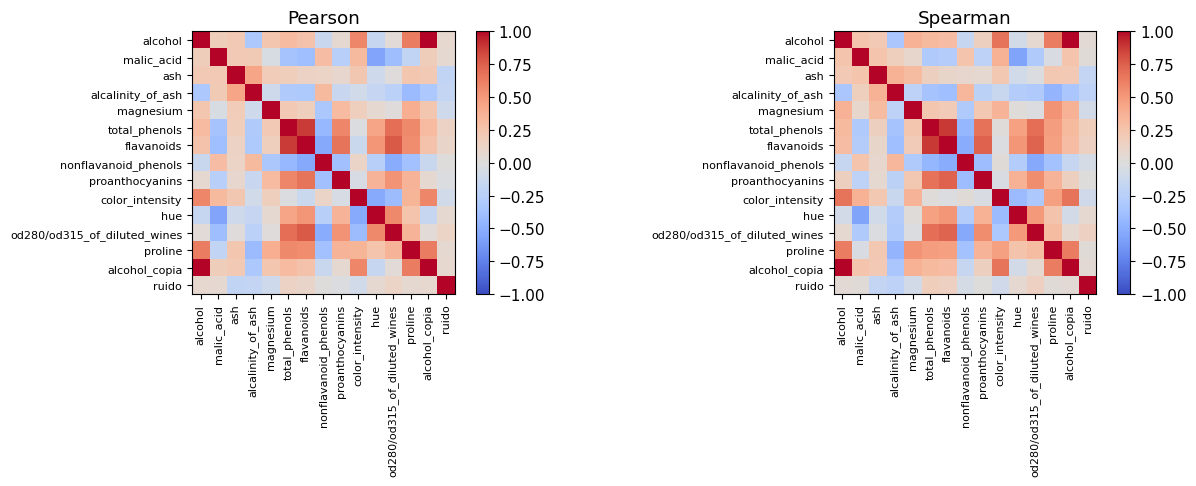

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metodo in zip(axes, ['pearson', 'spearman']):
    corr = Xt.corr(method=metodo)
    imagen = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=8)
    ax.set_yticks(range(len(corr)), corr.columns, fontsize=8)
    ax.set_title(metodo.capitalize())
    fig.colorbar(imagen, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

In [8]:
def eliminar_correlacionadas(X_entrenamiento, metodo='pearson', umbral=0.95):
    correlaciones = X_entrenamiento.corr(method=metodo).abs()
    conservar = []
    for columna in X_entrenamiento.columns:
        # Se compara solo con las variables que ya se conservaron.
        if not conservar or (correlaciones.loc[columna, conservar] <= umbral).all():
            conservar.append(columna)
    return conservar

for metodo in ['pearson', 'spearman']:
    t0 = perf_counter()
    nombre = f'Redundancia {metodo}'
    subconjuntos[nombre] = eliminar_correlacionadas(Xt, metodo=metodo)
    tiempos_seleccion[nombre] = perf_counter() - t0
    print(nombre, '- eliminadas:', [c for c in Xt if c not in subconjuntos[nombre]])

Redundancia pearson - eliminadas: ['alcohol_copia']
Redundancia spearman - eliminadas: ['alcohol_copia']


### 4.3. Correlación con el objetivo
No calculamos correlación con los códigos 0, 1 y 2: hacerlo introduciría un orden artificial. Como demostración, convertimos cada clase en un indicador binario y calculamos la correlación de cada variable con cada indicador. La puntuación es la **mayor correlación absoluta** entre las tres clases.

Este es un filtro heurístico univariado, no un contraste global multiclase. En un problema de regresión sí podríamos correlacionar directamente cada variable con el objetivo continuo.

In [9]:
puntuaciones_corr = {}
for metodo in ['pearson', 'spearman']:
    t0 = perf_counter()
    por_clase = pd.DataFrame({
        f'clase_{c}': Xt.corrwith((y_train == c).astype(int), method=metodo).abs()
        for c in sorted(y_train.unique())
    })
    puntuacion = por_clase.max(axis=1).sort_values(ascending=False)
    nombre = f'Objetivo {metodo}'
    subconjuntos[nombre] = puntuacion.head(K).index.tolist()
    tiempos_seleccion[nombre] = perf_counter() - t0
    puntuaciones_corr[metodo] = puntuacion

display(pd.DataFrame(puntuaciones_corr).sort_values('pearson', ascending=False).round(3))

,pearson,spearman
proline,0.830,0.784
od280/od315_of_diluted_wines,0.774,0.725
flavanoids,0.747,0.730
alcohol_copia,0.744,0.752
alcohol,0.744,0.752
color_intensity,0.731,0.803
hue,0.715,0.713
total_phenols,0.664,0.670
malic_acid,0.587,0.549
alcalinity_of_ash,0.517,0.560


### 4.4. ANOVA: diferencias entre clases
ANOVA compara la separación de las medias entre clases con la dispersión dentro de ellas:

$$F_j=\frac{\text{variación entre clases}}{\text{variación dentro de las clases}}.$$

Un valor alto sugiere que la variable ayuda a distinguir clases. `SelectKBest` conserva las cinco mayores puntuaciones. Los valores p no se usarán como prueba causal ni como evidencia clínica: aquí empleamos el estadístico para ordenar variables; la interpretación inferencial exige revisar supuestos y comparaciones múltiples.

In [10]:
t0 = perf_counter()
filtro_anova = SelectKBest(score_func=f_classif, k=K).fit(Xt, y_train)
subconjuntos['ANOVA'] = Xt.columns[filtro_anova.get_support()].tolist()
tiempos_seleccion['ANOVA'] = perf_counter() - t0

tabla_anova = pd.DataFrame({
    'F': filtro_anova.scores_, 'p': filtro_anova.pvalues_,
    'seleccionada': filtro_anova.get_support()
}, index=Xt.columns).sort_values('F', ascending=False)
display(tabla_anova.round(4))

,F,p,seleccionada
flavanoids,165.0047,0.0000,True
proline,120.1768,0.0000,True
od280/od315_of_diluted_wines,96.8679,0.0000,True
alcohol,84.8729,0.0000,True
alcohol_copia,84.8729,0.0000,True
color_intensity,79.3460,0.0000,False
total_phenols,66.0224,0.0000,False
hue,54.0571,0.0000,False
malic_acid,28.9871,0.0000,False
alcalinity_of_ash,19.5763,0.0000,False


### 4.5. Chi-cuadrada: indicadores no negativos
Chi-cuadrada compara frecuencias observadas y esperadas bajo independencia:

$$\chi^2=\sum\frac{(O-E)^2}{E}.$$

Para evitar aplicar el filtro a mediciones continuas con unidades arbitrarias, convertimos cada característica en un indicador: **1 si supera su mediana de entrenamiento y 0 en otro caso**. `chi2` puntúa la distribución de estas presencias entre las clases. No se aplica sobre datos estandarizados, que pueden contener valores negativos.

La selección se calcula con los indicadores, pero conservamos las **columnas originales continuas** para entrenar el clasificador común. Así comparamos subconjuntos bajo el mismo modelo final. La binarización pierde información y puede cambiar el ranking.

In [11]:
t0 = perf_counter()
medianas = Xt.median()
X_indicadores = (Xt > medianas).astype(int)
filtro_chi = SelectKBest(score_func=chi2, k=K).fit(X_indicadores, y_train)
subconjuntos['Chi-cuadrada'] = Xt.columns[filtro_chi.get_support()].tolist()
tiempos_seleccion['Chi-cuadrada'] = perf_counter() - t0

display(pd.DataFrame({
    'chi2': filtro_chi.scores_, 'seleccionada': filtro_chi.get_support()
}, index=Xt.columns).sort_values('chi2', ascending=False).round(3))

,chi2,seleccionada
color_intensity,33.663,True
flavanoids,33.047,True
total_phenols,31.189,True
alcohol_copia,28.258,True
alcohol,28.258,True
proline,27.845,False
od280/od315_of_diluted_wines,23.761,False
hue,18.960,False
nonflavanoid_phenols,17.908,False
proanthocyanins,17.854,False


### 4.6. Información mutua
Mide cuánto informa una variable acerca del objetivo. Para variables discretas:

$$I(X;Y)=\sum_{x,y}p(x,y)\log\frac{p(x,y)}{p(x)p(y)}.$$

Puede detectar relaciones no lineales. Aquí las entradas son continuas y el objetivo discreto; scikit-learn usa un estimador basado en vecinos. Una puntuación estimada en cero no demuestra irrelevancia conjunta. Al ser un filtro univariado, también puede conservar variables redundantes.

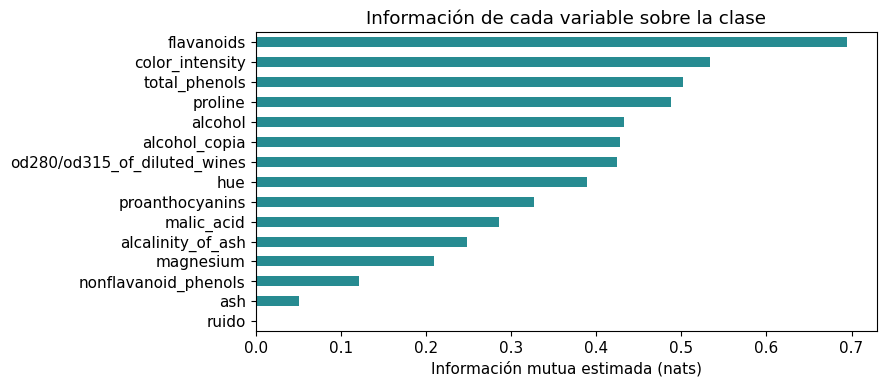

In [12]:
t0 = perf_counter()
mi = mutual_info_classif(Xt, y_train, discrete_features=False, random_state=SEED)
puntuacion_mi = pd.Series(mi, index=Xt.columns).sort_values(ascending=False)
subconjuntos['Información mutua'] = puntuacion_mi.head(K).index.tolist()
tiempos_seleccion['Información mutua'] = perf_counter() - t0

puntuacion_mi.sort_values().plot.barh(color='#278b91')
plt.xlabel('Información mutua estimada (nats)')
plt.title('Información de cada variable sobre la clase')
plt.tight_layout()
plt.show()

## 5. Métodos wrapper: evaluar subconjuntos con un modelo
### 5.1. Forward selection y backward elimination
**Forward:** parte sin variables y añade la que más mejora el F1 macro de validación cruzada.  
**Backward:** parte con todas y elimina la que deja el mejor F1 macro de validación cruzada.

Ambos terminan al conservar `K=5`. En esta práctica no exigimos una mejora mínima en cada paso. Son búsquedas greedy: una elección local no garantiza el mejor subconjunto global. Pueden tardar más que los filtros porque entrenan muchos modelos.

El escalador está dentro del estimador que recibe `SequentialFeatureSelector`, por lo que se vuelve a ajustar en cada fold. El resultado de esa búsqueda es interno al entrenamiento; no es una estimación final del desempeño.

In [13]:
selectores_secuenciales = {}
for direccion, nombre in [('forward', 'Forward'), ('backward', 'Backward')]:
    t0 = perf_counter()
    selector = SequentialFeatureSelector(
        crear_modelo(), n_features_to_select=K, direction=direccion,
        scoring='f1_macro', cv=cv, n_jobs=1
    )
    selector.fit(X_train, y_train)
    subconjuntos[nombre] = X_train.columns[selector.get_support()].tolist()
    tiempos_seleccion[nombre] = perf_counter() - t0
    selectores_secuenciales[nombre] = selector
    print(nombre, ':', subconjuntos[nombre])

Forward : ['alcohol', 'flavanoids', 'color_intensity', 'hue', 'proline']
Backward : ['flavanoids', 'color_intensity', 'hue', 'proline', 'alcohol_copia']


### 5.2. RFE: eliminación recursiva por importancia
RFE entrena el modelo, elimina la variable con menor importancia y vuelve a entrenar hasta conservar `K` variables. Aquí la importancia viene de los coeficientes de regresión logística sobre datos estandarizados.

**Diferencia con backward:** backward prueba exclusiones usando validación cruzada; RFE elimina según coeficientes o importancias del modelo ajustado. `ranking_=1` identifica las variables conservadas. Fijamos `K` de antemano; `RFECV` sería una extensión para elegirlo mediante validación cruzada.

In [14]:
t0 = perf_counter()
rfe = RFE(
    estimator=crear_modelo(), n_features_to_select=K, step=1,
    importance_getter='named_steps.logisticregression.coef_'
)
rfe.fit(X_train, y_train)
subconjuntos['RFE'] = X_train.columns[rfe.get_support()].tolist()
tiempos_seleccion['RFE'] = perf_counter() - t0

display(pd.DataFrame({
    'ranking': rfe.ranking_, 'seleccionada': rfe.support_
}, index=X_train.columns).sort_values('ranking'))

,ranking,seleccionada
flavanoids,1,True
alcohol_copia,1,True
hue,1,True
color_intensity,1,True
proline,1,True
od280/od315_of_diluted_wines,2,False
ash,3,False
alcalinity_of_ash,4,False
alcohol,5,False
proanthocyanins,6,False


## 6. Métodos integrados o embedded
### 6.1. Regularización L1 y Elastic Net
La regularización añade una penalización a la pérdida:

$$L_{total}=L_{datos}+\lambda\left[\rho\|\beta\|_1+\frac{1-\rho}{2}\|\beta\|_2^2\right].$$

- `l1_ratio=1`: L1; puede dejar coeficientes exactamente en cero.
- `l1_ratio=0.5`: Elastic Net; combina L1 y L2.
- `l1_ratio=0`: L2; reduce coeficientes, pero en general **no selecciona** variables por sí sola.

En regresión logística, un `C` menor implica regularización más fuerte. Usamos `C=0.1` como valor didáctico, sin optimizarlo. En multiclase cada variable tiene varios coeficientes; conservamos una columna si la suma de sus valores absolutos supera una tolerancia numérica.

Lasso aplica una penalización L1 a la regresión de un objetivo continuo; aquí usamos su alternativa para clasificación: regresión logística L1.

In [15]:
escalador_integrados = StandardScaler().fit(Xt)
Xt_std = escalador_integrados.transform(Xt)
coeficientes = {}

for nombre, proporcion in [('Logística L1', 1.0), ('Elastic Net', 0.5), ('L2 (referencia)', 0.0)]:
    t0 = perf_counter()
    modelo = LogisticRegression(
        solver='saga', l1_ratio=proporcion, C=0.1,
        max_iter=10000, tol=1e-5, random_state=SEED
    ).fit(Xt_std, y_train)
    coeficientes[nombre] = np.abs(modelo.coef_).sum(axis=0)
    if proporcion > 0:
        selector = SelectFromModel(modelo, prefit=True, threshold=1e-6)
        columnas = Xt.columns[selector.get_support()].tolist()
        if not columnas:
            raise ValueError('Ninguna variable seleccionada: aumenta C y vuelve a ejecutar.')
        subconjuntos[nombre] = columnas
        tiempos_seleccion[nombre] = perf_counter() - t0

display(pd.DataFrame(coeficientes, index=Xt.columns).round(4))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


,Logística L1,Elastic Net,L2 (referencia)
alcohol,0.7123,0.7123,0.7123
malic_acid,0.5611,0.5611,0.5611
ash,0.5788,0.5788,0.5788
alcalinity_of_ash,0.6868,0.6868,0.6868
magnesium,0.1172,0.1172,0.1172
total_phenols,0.4718,0.4718,0.4718
flavanoids,0.7890,0.7890,0.7890
nonflavanoid_phenols,0.3329,0.3329,0.3329
proanthocyanins,0.4317,0.4317,0.4317
color_intensity,0.9179,0.9179,0.9179


### 6.2. Importancia de árboles: Random Forest
Un bosque combina árboles y proporciona importancias basadas en la reducción acumulada de impureza. `SelectFromModel` transforma ese ranking en una selección: conservaremos las columnas cuya importancia alcance la media.

El bosque aprende importancias durante el entrenamiento; el umbral crea el subconjunto. Después lo evaluaremos con el mismo clasificador lineal usado en los otros métodos. Por ello, una variable útil para el bosque podría ser menos útil para ese clasificador. Las importancias de impureza pueden favorecer variables con más puntos de corte y repartir importancia entre variables correlacionadas.

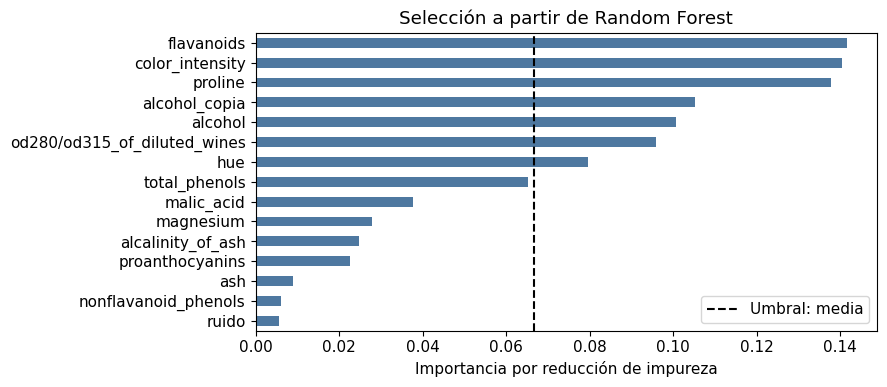

In [16]:
t0 = perf_counter()
bosque = RandomForestClassifier(
    n_estimators=150, min_samples_leaf=2, random_state=SEED, n_jobs=1
).fit(Xt, y_train)
selector_bosque = SelectFromModel(bosque, prefit=True, threshold='mean')
subconjuntos['Random Forest'] = Xt.columns[selector_bosque.get_support()].tolist()
tiempos_seleccion['Random Forest'] = perf_counter() - t0

importancias = pd.Series(bosque.feature_importances_, index=Xt.columns).sort_values()
importancias.plot.barh(color='#4e78a0')
plt.axvline(importancias.mean(), color='black', linestyle='--', label='Umbral: media')
plt.xlabel('Importancia por reducción de impureza')
plt.title('Selección a partir de Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Búsqueda global: recocido simulado
Esta sección es una ampliación del recorrido básico. Representamos un subconjunto con una máscara de ceros y unos. Buscamos maximizar:

$$J(S)=F1_{macro,CV}(S)-\lambda\frac{|S|}{p}.$$

El primer término premia el desempeño y el segundo penaliza conservar muchas variables. A diferencia de forward/backward, el algoritmo puede añadir o recuperar variables y aceptar temporalmente una solución peor.

1. Comenzar con una máscara aleatoria no vacía.
2. Cambiar el estado de una variable.
3. Aceptar siempre una mejora; aceptar un empeoramiento con probabilidad $\exp(\Delta J/T)$.
4. Reducir la temperatura $T$ y conservar la mejor solución visitada.

Usamos un presupuesto pequeño de **60 iteraciones**. Este método no garantiza el óptimo global. Las puntuaciones se calculan solo con validación cruzada dentro de entrenamiento; se reutilizan los mismos folds para comparar candidatos.

Seleccionadas: ['alcohol', 'malic_acid', 'alcalinity_of_ash', 'flavanoids', 'color_intensity', 'proline', 'ruido']
Subconjuntos distintos evaluados: 54
F1 CV del mejor candidato: 0.990


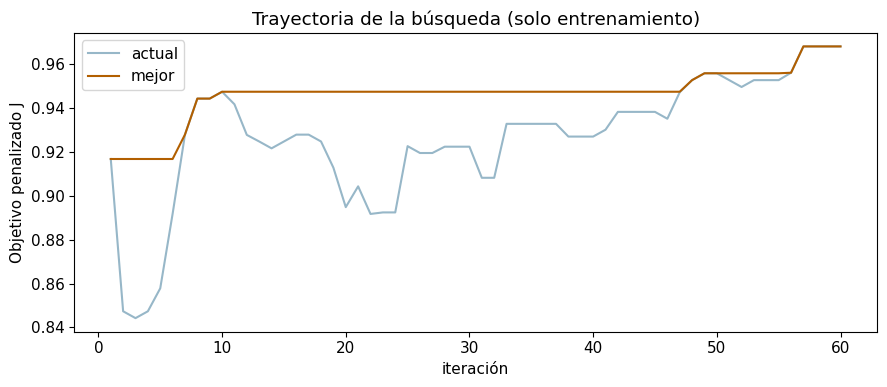

In [17]:
LAMBDA = 0.05
N_ITER = 60
p = X_train.shape[1]
cache = {}

def evaluar_mascara(mascara):
    clave = tuple(mascara)
    if clave not in cache:
        columnas = X_train.columns[mascara]
        f1_cv = cross_val_score(
            crear_modelo(), X_train[columnas], y_train,
            scoring='f1_macro', cv=cv, n_jobs=1
        ).mean()
        objetivo = f1_cv - LAMBDA * mascara.sum() / p
        cache[clave] = (objetivo, f1_cv)
    return cache[clave]

t0 = perf_counter()
rng_sa = np.random.default_rng(SEED)
actual = rng_sa.random(p) < 0.5
if not actual.any():
    actual[0] = True
j_actual, _ = evaluar_mascara(actual)
mejor = actual.copy()
j_mejor = j_actual
historial = []

for paso in range(N_ITER):
    temperatura = 0.04 * (0.95 ** paso)
    candidata = actual.copy()
    indice = rng_sa.integers(p)
    candidata[indice] = not candidata[indice]
    if not candidata.any():
        candidata[indice] = True  # Impedir un subconjunto vacío.

    j_candidata, _ = evaluar_mascara(candidata)
    diferencia = j_candidata - j_actual
    if diferencia >= 0 or rng_sa.random() < np.exp(diferencia / temperatura):
        actual, j_actual = candidata, j_candidata
    if j_actual > j_mejor:
        mejor, j_mejor = actual.copy(), j_actual
    historial.append({'iteración': paso + 1, 'actual': j_actual, 'mejor': j_mejor})

subconjuntos['Recocido simulado'] = X_train.columns[mejor].tolist()
tiempos_seleccion['Recocido simulado'] = perf_counter() - t0
print('Seleccionadas:', subconjuntos['Recocido simulado'])
print('Subconjuntos distintos evaluados:', len(cache))
print(f'F1 CV del mejor candidato: {evaluar_mascara(mejor)[1]:.3f}')
pd.DataFrame(historial).set_index('iteración').plot(color=['#97b7c8', '#b25f00'])
plt.ylabel('Objetivo penalizado J')
plt.title('Trayectoria de la búsqueda (solo entrenamiento)')
plt.tight_layout()
plt.show()

## 8. Comparación de los métodos
### 8.1. Desempeño en validación
Cada subconjunto se evalúa entrenando **el mismo pipeline** de estandarización y regresión logística sobre entrenamiento. Las variables originales conservan sus valores; no reutilizamos los indicadores de chi-cuadrada ni el bosque como clasificador final.

Los tiempos reportados corresponden al bloque principal de cada selección; excluyen visualización y, cuando se comparte, el preprocesamiento previo. Son orientativos y dependen del equipo. No todos los métodos tienen el mismo presupuesto computacional ni conservan el mismo número de columnas.

In [18]:
resultados = []
for nombre, columnas in subconjuntos.items():
    modelo = crear_modelo().fit(X_train[columnas], y_train)
    prediccion = modelo.predict(X_val[columnas])
    resultados.append({
        'método': nombre,
        'n_variables': len(columnas),
        'reducción_%': 100 * (1 - len(columnas) / X_train.shape[1]),
        'F1_val': f1_score(y_val, prediccion, average='macro'),
        'accuracy_val': accuracy_score(y_val, prediccion),
        'selección_s': tiempos_seleccion[nombre]
    })
comparacion = pd.DataFrame(resultados).set_index('método')
display(comparacion.sort_values(['F1_val', 'n_variables'], ascending=[False, True]).round(3))

,n_variables,reducción_%,F1_val,accuracy_val,selección_s
método,,,,,
Información mutua,5,68.75,1.000,1.000,0.127
Redundancia pearson,14,12.50,1.000,1.000,0.025
Redundancia spearman,14,12.50,1.000,1.000,0.013
Varianza,15,6.25,1.000,1.000,0.012
Logística L1,15,6.25,1.000,1.000,0.021
Elastic Net,15,6.25,1.000,1.000,0.016
Sin selección,16,0.00,1.000,1.000,0.000
Objetivo pearson,5,68.75,0.974,0.972,0.032
ANOVA,5,68.75,0.974,0.972,0.009


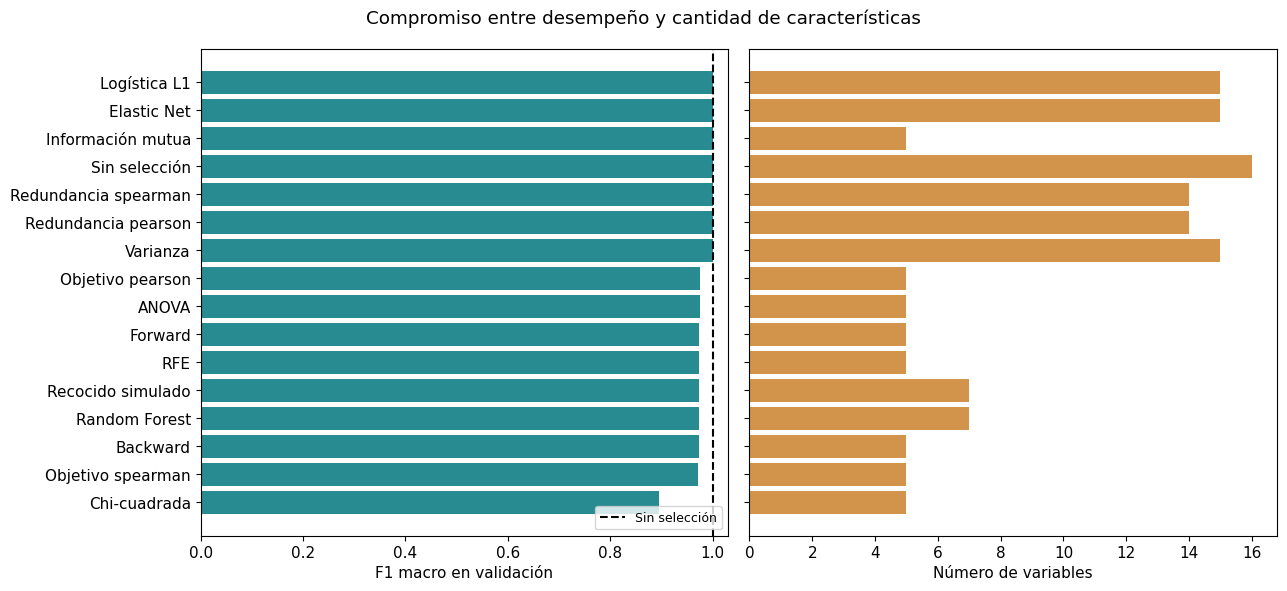

In [19]:
orden = comparacion.sort_values('F1_val').index
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
axes[0].barh(orden, comparacion.loc[orden, 'F1_val'], color='#278b91')
axes[0].axvline(comparacion.loc['Sin selección', 'F1_val'],
                color='black', linestyle='--', label='Sin selección')
axes[0].set_xlim(0, 1.03)
axes[0].set_xlabel('F1 macro en validación')
axes[0].legend(loc='lower right', fontsize=9)
axes[1].barh(orden, comparacion.loc[orden, 'n_variables'], color='#d2944a')
axes[1].set_xlabel('Número de variables')
fig.suptitle('Compromiso entre desempeño y cantidad de características')
plt.tight_layout()
plt.show()

### 8.2. ¿Coinciden las variables seleccionadas?
Cada celda oscura indica que el método conserva esa característica. Observa especialmente `constante`, `alcohol_copia` y `ruido`. Que dos métodos consigan un F1 parecido no significa que hayan elegido las mismas columnas.

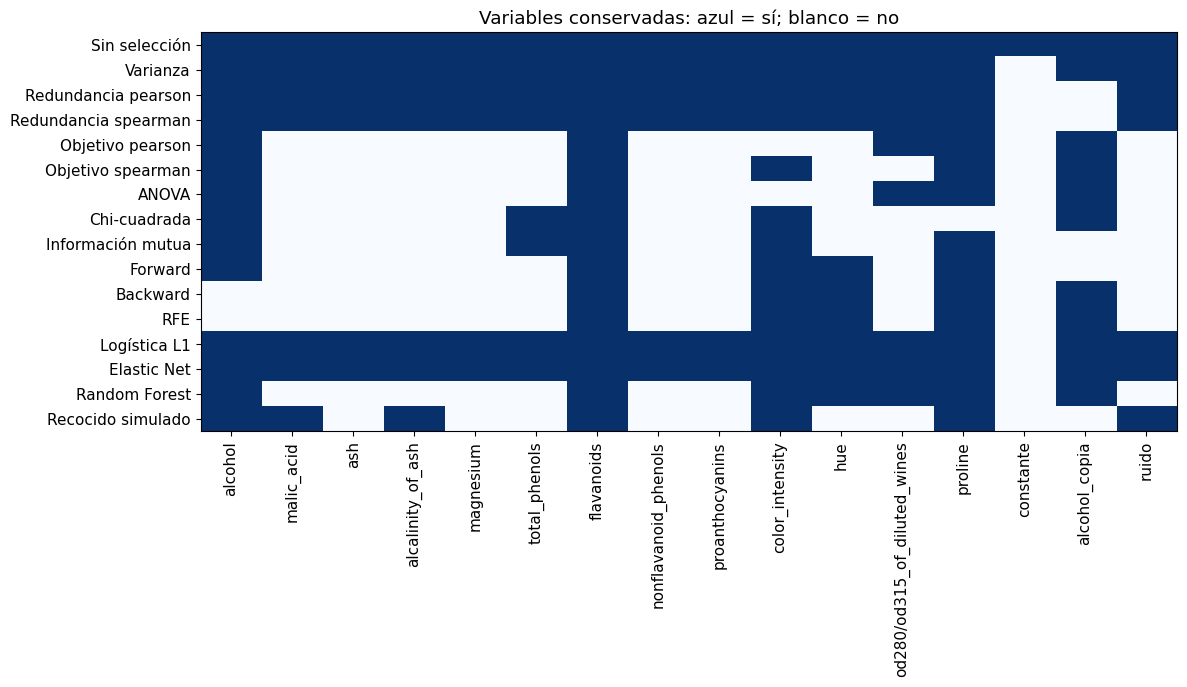

In [20]:
matriz_seleccion = pd.DataFrame({
    nombre: X.columns.isin(columnas).astype(int)
    for nombre, columnas in subconjuntos.items()
}, index=X.columns).T

fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(matriz_seleccion, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(X.columns)), X.columns, rotation=90)
ax.set_yticks(range(len(matriz_seleccion)), matriz_seleccion.index)
ax.set_title('Variables conservadas: azul = sí; blanco = no')
plt.tight_layout()
plt.show()

### 8.3. Decisión con validación y evaluación final
Definimos una regla explícita: entre los métodos a **no más de 0.02 de F1 macro del mejor valor en validación**, elegimos el de menos variables; los empates se resuelven por mayor F1 y luego por nombre.

El margen de 0.02 es una preferencia didáctica, **no una prueba de equivalencia estadística**. Fijamos el subconjunto elegido, reentrenamos el clasificador con entrenamiento + validación y evaluamos una sola vez en prueba. No volvemos a seleccionar columnas con el conjunto combinado, para evaluar exactamente el subconjunto elegido.

Wine es pequeño: algunas predicciones pueden cambiar bastante las métricas. Esta práctica ilustra un procedimiento, no establece un método universalmente superior. Si se modifican reiteradamente las decisiones tras mirar prueba, ese conjunto deja de ser una evaluación independiente.

Método elegido con validación: Información mutua
Variables: ['flavanoids', 'color_intensity', 'total_phenols', 'proline', 'alcohol']
F1 macro en prueba: 0.971
Accuracy en prueba: 0.972


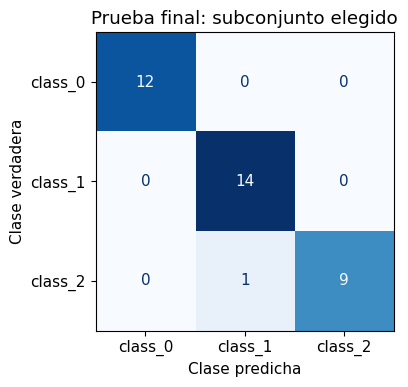

In [21]:
MARGEN_F1 = 0.02
candidatos = comparacion[
    comparacion['F1_val'] >= comparacion['F1_val'].max() - MARGEN_F1
].reset_index()
elegido = candidatos.sort_values(
    ['n_variables', 'F1_val', 'método'], ascending=[True, False, True]
).iloc[0]['método']
columnas_finales = subconjuntos[elegido]

modelo_final = crear_modelo().fit(X_desarrollo[columnas_finales], y_desarrollo)
pred_test = modelo_final.predict(X_test[columnas_finales])
print('Método elegido con validación:', elegido)
print('Variables:', columnas_finales)
print(f'F1 macro en prueba: {f1_score(y_test, pred_test, average="macro"):.3f}')
print(f'Accuracy en prueba: {accuracy_score(y_test, pred_test):.3f}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_test, display_labels=datos.target_names,
    cmap='Blues', colorbar=False, ax=ax
)
ax.set_title('Prueba final: subconjunto elegido')
ax.set_xlabel('Clase predicha')
ax.set_ylabel('Clase verdadera')
plt.tight_layout()
plt.show()

**Documentación de apoyo:**
- [Dataset Wine](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html).
- [Selección de características](https://scikit-learn.org/stable/modules/feature_selection.html).
- [Regresión logística y penalizaciones](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).
- [Requisitos de chi-cuadrada](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.chi2.html).

### Declaración de uso de IA generativa

Este notebook fue elaborado con apoyo de ChatGPT 6 (OpenAI) para estructurar el contenido a partir de las diapositivas de la sesión y redactar el texto explicativo. El diseño pedagógico, la selección de temas y la revisión final son responsabilidad del titular del curso.
